# Proyecto 2: PageRank sobre redes reales

**Integrantes del grupo:**
- TODO: Nombre completo 1
- TODO: Nombre completo 2
- TODO: Nombre completo 3 (opcional)

**Red elegida (KONECT):** TODO: nombre de la red y enlace directo a http://konect.cc

---

## Tabla de contenidos

1. [Setup e imports](#1.-Setup-e-imports)
2. [P1 — Elección y descripción de la red](#2.-P1:-Elección-y-descripción-de-la-red)
3. [P2 — Pregunta e hipótesis inicial](#3.-P2:-Pregunta-o-hipótesis-inicial)
4. [P3 — Análisis exploratorio de la red](#4.-P3:-Análisis-exploratorio-de-la-red)
5. [P4 — Construcción de la Matriz de Google](#5.-P4:-Construcción-de-la-Matriz-de-Google)
6. [P5 — Cálculo de PageRank mediante iteración de potencias](#6.-P5:-Cálculo-del-PageRank-mediante-iteración-de-potencias)
7. [P6 — PageRank vs. grado de entrada](#7.-P6:-PageRank-vs.-grado-de-entrada)
8. [P7 — Interpretación de resultados](#8.-P7:-Interpretación-de-resultados)
9. [P8 — Discusión, limitaciones y conclusiones](#9.-P8:-Discusión,-limitaciones-y-conclusiones)
10. [Checklist final y exportación](#10.-Checklist-final-y-exportación)

> **Nota metodológica:** Este notebook es un **esqueleto reproducible**. Cada
> `# TODO` marca una decisión que el grupo debe tomar explícitamente (elección
> de la red, parámetro `alpha`, interpretación de resultados, etc.). El código
> matemático (construcción de `H`, `S`, `G` e iteración de potencias) está
> implementado de forma genérica y eficiente (matrices dispersas de `scipy`),
> pero **deben entenderlo y poder explicarlo** — no debe usarse como caja negra.


## 1. Setup e imports

Importamos las librerías esperadas por el enunciado: `numpy`/`scipy` para
álgebra lineal, `scipy.sparse` para representar `H`/`S`/`G` de forma
eficiente (fundamental porque redes reales con miles de nodos generan
matrices densas de tamaño $n^2$ que no caben en memoria), `networkx` para
construcción del grafo y métricas, `matplotlib`/`seaborn` para
visualización, y `urllib`/`requests` para descargar el dataset desde
KONECT.

Todos los parámetros configurables del proyecto están centralizados en la
siguiente celda para que la ejecución sea reproducible de principio a fin.


In [25]:
# --- Librerías estándar ---
import os
import io
import gzip
import zipfile
import urllib.request
from pathlib import Path

# --- Álgebra lineal y datos ---
import numpy as np
import scipy.sparse as sp
from scipy.stats import pearsonr

# --- Grafos ---
import networkx as nx

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Reproducibilidad ---
SEED = 42
np.random.seed(SEED)

In [26]:
# =============================================================
# PARÁMETROS CONFIGURABLES DEL PROYECTO
# =============================================================
# TODO: Completar con la información real de la red elegida en KONECT
# (http://konect.cc/networks/). La red debe ser DIRIGIDA, con al menos
# 500 nodos y 2000 aristas, y tener un contexto interpretable.

KONECT_NETWORK_NAME = "	facebook-wosn-wall"      # TODO: p.ej. "moreno_blogs", "cit-HepPh", etc.
KONECT_DOWNLOAD_URL  = "http://konect.cc/files/download.tsv.facebook-wosn-wall.tar.bz2"  # TODO: URL directa al .tar.bz2 / .zip del dataset en KONECT

# Carpeta local donde se guardarán los datos descargados/descomprimidos
DATA_DIR = Path("data")
RAW_DATA_PATH = DATA_DIR / "raw"          # TODO: ajustar si el nombre de archivo difiere
EDGES_FILENAME = "facebook-wosn-wall/out.facebook-wosn-wall"  # TODO: nombre del archivo de aristas dentro del paquete KONECT

# Parámetro de amortiguamiento (damping factor) de PageRank.
# El enunciado sugiere alpha ~ 0.85 (valor estándar usado por Google/literatura clásica).
ALPHA = 0.85  # TODO: justificar en el informe por qué se usa este valor (o uno alternativo)

# Tolerancia y máximo de iteraciones para la iteración de potencias
TOL = 1e-10
MAX_ITER = 1000

# Cantidad de nodos a reportar/visualizar en distintas secciones (fijado por el enunciado)
TOP_N_DEGREE = 10     # P3(c): top 10 nodos por grado de entrada/salida
TOP_N_PAGERANK = 20   # P5(d): top 20 nodos por PageRank
SUBGRAPH_SIZE = 40    # P7(b): subgrafo inducido por 30 a 50 nodos de mayor PageRank -> TODO ajustar (30-50)

# Semilla para cualquier proceso estocástico (layouts de grafos, muestreos, etc.)
RANDOM_STATE = SEED

DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)

print("Parámetros configurados. Recuerda completar los TODO antes de ejecutar el resto del notebook.")


Parámetros configurados. Recuerda completar los TODO antes de ejecutar el resto del notebook.


## 2. P1: Elección y descripción de la red

**Consigna del enunciado:** elegir una red dirigida de KONECT con al menos
500 nodos y 2 000 aristas, con contexto real e interpretable (no sintética).
Se debe describir la fuente de los datos (qué representan nodos y aristas,
contexto de recolección) y presentar una tabla con estadísticas básicas:
$n$, $m$, $\bar d^{in}$, $\bar d^{out}$, nodo de mayor grado de entrada,
densidad $m/(n(n-1))$ y cantidad de nodos colgantes.

### 2.1 Descripción de la fuente de datos

> TODO: Reemplazar este párrafo por una descripción real de la red elegida.
> Debe responder:
> - ¿Qué representan los **nodos**? (p.ej. usuarios, artículos, páginas web)
> - ¿Qué representan las **aristas**? (p.ej. "cita a", "sigue a", "enlaza a")
> - ¿En qué **contexto** fue recopilada la red (fuente original, año, dominio)?
> - ¿Por qué **eligieron** esta red en particular?

### 2.2 Descarga de los datos

La siguiente celda descarga el dataset directamente desde KONECT. Si el
formato del archivo descargado difiere (algunos paquetes KONECT vienen como
`.tar.bz2`, otros como `.zip`), ajusten la lógica de descompresión.


In [27]:
def descargar_dataset_konect(url: str, destino: Path) -> Path:
    """Descarga el dataset de KONECT si no existe localmente.

    Parameters
    ----------
    url : str
        URL de descarga directa del dataset (ver TODO en parámetros).
    destino : Path
        Carpeta donde se guardará el archivo descargado.

    Returns
    -------
    Path
        Ruta al archivo descargado.
    """
    destino.mkdir(parents=True, exist_ok=True)
    nombre_archivo = url.split("/")[-1] or "dataset_konect.download"
    ruta_local = destino / nombre_archivo

    if ruta_local.exists():
        print(f"El archivo ya existe localmente en: {ruta_local}")
        return ruta_local

    try:
        print(f"Descargando desde {url} ...")
        urllib.request.urlretrieve(url, ruta_local)
        print(f"Descarga completa: {ruta_local}")
    except Exception as e:
        raise RuntimeError(
            "No se pudo descargar el dataset. Verifica KONECT_DOWNLOAD_URL "
            f"y tu conexión a internet. Error original: {e}"
        )
    return ruta_local


# TODO: descomentar y ejecutar una vez que KONECT_DOWNLOAD_URL esté completo
archivo_descargado = descargar_dataset_konect(KONECT_DOWNLOAD_URL, RAW_DATA_PATH)

# TODO: si el archivo viene comprimido (.tar.bz2, .zip, .gz), descomprimirlo aquí.
# Ejemplo genérico para .zip:
import tarfile
os.makedirs("data/raw", exist_ok=True)

tar = tarfile.open("data/raw/download.tsv.facebook-wosn-wall.tar.bz2", "r:bz2")
tar.extractall(path="data/raw")
tar.close()


El archivo ya existe localmente en: data/raw/download.tsv.facebook-wosn-wall.tar.bz2


/tmp/ipykernel_18040/976842830.py:45: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="data/raw")


In [28]:
def cargar_grafo_desde_edgelist(ruta_edgelist: Path) -> nx.DiGraph:
    """Carga una lista de aristas en formato KONECT (u v [peso] [timestamp])
    como un grafo dirigido de networkx.

    Los archivos KONECT suelen tener líneas de comentario que empiezan con '%'.
    Se asume, por defecto, que las dos primeras columnas son (origen, destino).

    Parameters
    ----------
    ruta_edgelist : Path
        Ruta al archivo de aristas (p.ej. 'out.nombre_red').

    Returns
    -------
    nx.DiGraph
        Grafo dirigido cargado.
    """
    if not ruta_edgelist.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo de aristas en {ruta_edgelist}. "
            "Verifica EDGES_FILENAME y que el dataset haya sido descomprimido."
        )

    G = nx.DiGraph()
    with open(ruta_edgelist, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            linea = linea.strip()
            if not linea or linea.startswith("%"):
                continue
            partes = linea.split()
            if len(partes) < 2:
                continue
            u, v = partes[0], partes[1]
            G.add_edge(u, v)

    assert G.number_of_nodes() > 0, "El grafo cargado no tiene nodos. Revisa el formato del archivo."
    return G


# TODO: ajustar la ruta al archivo de aristas real dentro del paquete descomprimido
ruta_edges = RAW_DATA_PATH / EDGES_FILENAME

print(os.getcwd())
print(ruta_edges)

try:
    G = cargar_grafo_desde_edgelist(ruta_edges)
    print(f"Grafo cargado: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas.")
except FileNotFoundError as e:
    print('No se encontro archivo.')


/home/uc/Downloads/IMT2230/Tareas/Proyecto2/Proyecto-Algebra2
data/raw/facebook-wosn-wall/out.facebook-wosn-wall
Grafo cargado: 46952 nodos, 274086 aristas.


### 2.3 Validación de los requisitos mínimos de la red

Verificamos que la red cumpla las condiciones exigidas por el enunciado:
al menos 500 nodos, al menos 2 000 aristas y que sea efectivamente dirigida.


In [29]:
n_nodos = G.number_of_nodes()
n_aristas = G.number_of_edges()

assert G.is_directed(), "La red debe ser dirigida (nx.DiGraph)."
assert n_nodos >= 500, f"Se requieren al menos 500 nodos; la red tiene {n_nodos}."
assert n_aristas >= 2000, f"Se requieren al menos 2000 aristas; la red tiene {n_aristas}."

print("La red cumple los requisitos mínimos del enunciado:")
print(f"  - Dirigida: {G.is_directed()}")
print(f"  - Nodos: {n_nodos} (>= 500 requerido)")
print(f"  - Aristas: {n_aristas} (>= 2000 requerido)")


La red cumple los requisitos mínimos del enunciado:
  - Dirigida: True
  - Nodos: 46952 (>= 500 requerido)
  - Aristas: 274086 (>= 2000 requerido)


### 2.4 Tabla de estadísticas básicas de la red

Calculamos: número de nodos $n$, número de aristas $m$, grado de entrada
medio $\bar d^{in}$, grado de salida medio $\bar d^{out}$, nodo de mayor
grado de entrada, densidad $m/(n(n-1))$ y cantidad de nodos colgantes (sin
aristas de salida).


In [30]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

n = G.number_of_nodes()
m = G.number_of_edges()

d_in_medio = np.mean(list(in_degrees.values()))
d_out_medio = np.mean(list(out_degrees.values()))

nodo_max_in = max(in_degrees, key=in_degrees.get)
densidad = m / (n * (n - 1))

nodos_colgantes = [nodo for nodo, d in out_degrees.items() if d == 0]
n_colgantes = len(nodos_colgantes)
frac_colgantes = n_colgantes / n

tabla_estadisticas = {
    "Número de nodos (n)": n,
    "Número de aristas (m)": m,
    "Grado de entrada medio": round(d_in_medio, 4),
    "Grado de salida medio": round(d_out_medio, 4),
    "Nodo de mayor grado de entrada": nodo_max_in,
    "Grado de entrada del nodo anterior": in_degrees[nodo_max_in],
    "Densidad m/(n(n-1))": densidad,
    "Cantidad de nodos colgantes": n_colgantes,
    "Fracción de nodos colgantes": round(frac_colgantes, 4),
}

for k, v in tabla_estadisticas.items():
    print(f"{k:35s}: {v}")

# TODO: transcribir esta tabla al informe final (formato tabla, no solo print)


Número de nodos (n)                : 46952
Número de aristas (m)              : 274086
Grado de entrada medio             : 5.8376
Grado de salida medio              : 5.8376
Nodo de mayor grado de entrada     : 2420
Grado de entrada del nodo anterior : 199
Densidad m/(n(n-1))                : 0.00012433342855071923
Cantidad de nodos colgantes        : 4562
Fracción de nodos colgantes        : 0.0972


## 3. P2: Pregunta o hipótesis inicial (Motivación)

**Consigna:** formular una pregunta concreta anclada en el contexto de la
red elegida, y proponer una hipótesis inicial sobre qué nodos tendrán mayor
PageRank **antes** de calcularlo, basada en conocimiento de dominio o en la
exploración preliminar.

> **Pregunta de investigación (TODO — completar):**
> ¿Qué [artículos / usuarios / páginas / entidades] son los más
> influyentes/centrales dentro de esta red, y qué los caracteriza?

> **Hipótesis inicial (TODO — completar):**
> Se espera que los nodos con TODO (p.ej. mayor grado de entrada, posición
> estratégica, pertenencia a cierta comunidad) obtengan mayor PageRank,
> porque TODO (justificación basada en el dominio del problema).

*Nota: esta hipótesis debe redactarse antes de mirar los resultados finales
de PageRank en la Sección 6, para poder contrastarla honestamente en la
Sección 9 (P8).*


## 4. P3: Análisis exploratorio de la red

Antes de calcular PageRank, exploramos la estructura de la red:

- (a) Distribución de grado de entrada y de salida.
- (b) Identificación y conteo de nodos colgantes, y por qué son
  problemáticos para PageRank (una columna de la matriz de hipervínculos
  $H$ correspondiente a un nodo colgante sumaría 0, rompiendo la propiedad
  de columna-estocástica necesaria para que $G$ sea una matriz de
  transición válida; esto se resuelve reemplazando esas columnas por el
  vector uniforme $\mathbf{1}/n$ al construir $S$).
- (c) Tabla/gráfico de los 10 nodos de mayor grado de entrada y salida.
- (d) Comentario sobre conexidad fuerte / componentes aisladas.


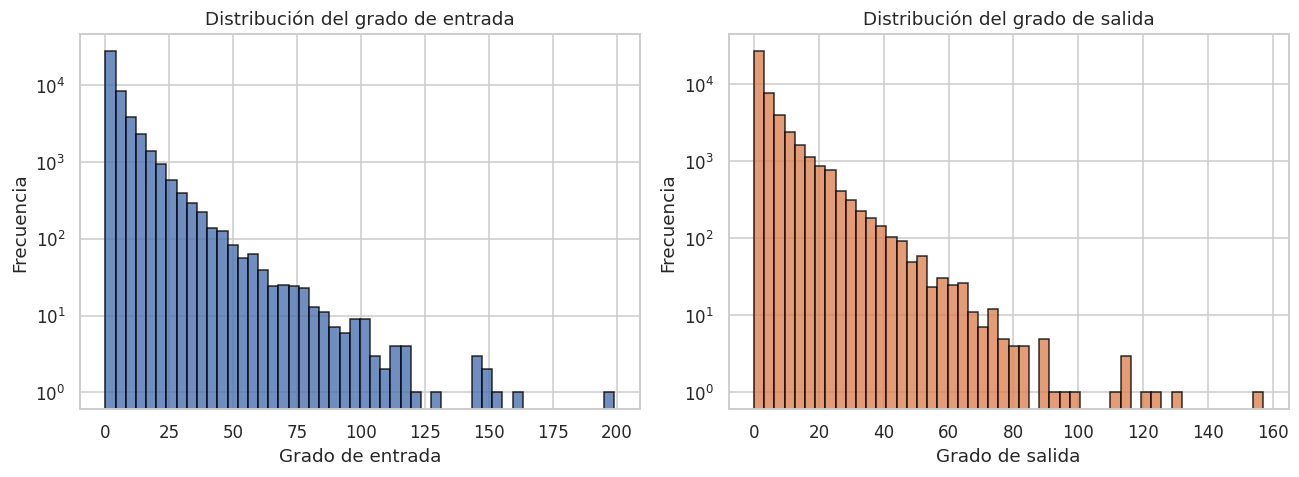

In [31]:
# --- (a) Distribución de grado de entrada y de salida ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

in_vals = list(in_degrees.values())
out_vals = list(out_degrees.values())

axes[0].hist(in_vals, bins=50, color="#4C72B0", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribución del grado de entrada")
axes[0].set_xlabel("Grado de entrada")
axes[0].set_ylabel("Frecuencia")
axes[0].set_yscale("log")

axes[1].hist(out_vals, bins=50, color="#DD8452", edgecolor="black", alpha=0.8)
axes[1].set_title("Distribución del grado de salida")
axes[1].set_xlabel("Grado de salida")
axes[1].set_ylabel("Frecuencia")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

# TODO: comentar en el informe la forma de estas distribuciones
# (p.ej. ¿son de tipo ley de potencias / long-tail, como es típico en redes reales?)


In [32]:
# --- (b) Nodos colgantes: identificación y conteo ---
print(f"Cantidad de nodos colgantes (grado de salida = 0): {n_colgantes}")
print(f"Fracción del total de nodos: {frac_colgantes:.2%}")
print()
print("Ejemplos de nodos colgantes (primeros 10):")
print(nodos_colgantes[:10])


Cantidad de nodos colgantes (grado de salida = 0): 4562
Fracción del total de nodos: 9.72%

Ejemplos de nodos colgantes (primeros 10):
['8', '18', '26', '42', '67', '126', '131', '141', '145', '152']


**¿Por qué son problemáticos los nodos colgantes?** Si un nodo $j$ no
tiene aristas salientes, la columna $j$ de $H$ es idénticamente cero
($\sum_i H_{ij} = 0$), por lo que $H$ deja de ser columna-estocástica. Esto
rompe la interpretación de $H$ como matriz de transición de una cadena de
Markov (la "marcha aleatoria" quedaría "atrapada" en ese nodo) y además
elimina la garantía de convergencia de la iteración de potencias. La
solución estándar es reemplazar cada columna cero por el vector uniforme
$\mathbf{1}/n$, obteniendo la matriz **columna-estocástica** $S$ (ver
Sección 5).


Top 10 nodos por grado de ENTRADA:
   1. nodo=2420            in-degree=199
   2. nodo=5706            in-degree=161
   3. nodo=7308            in-degree=154
   4. nodo=2611            in-degree=150
   5. nodo=2616            in-degree=150
   6. nodo=21015           in-degree=147
   7. nodo=6700            in-degree=145
   8. nodo=6765            in-degree=145
   9. nodo=9300            in-degree=129
  10. nodo=5684            in-degree=120

Top 10 nodos por grado de SALIDA:
   1. nodo=6765            out-degree=157
   2. nodo=518             out-degree=130
   3. nodo=7308            out-degree=124
   4. nodo=3017            out-degree=120
   5. nodo=2420            out-degree=115
   6. nodo=2611            out-degree=115
   7. nodo=4946            out-degree=114
   8. nodo=4034            out-degree=113
   9. nodo=2873            out-degree=100
  10. nodo=2616            out-degree=96


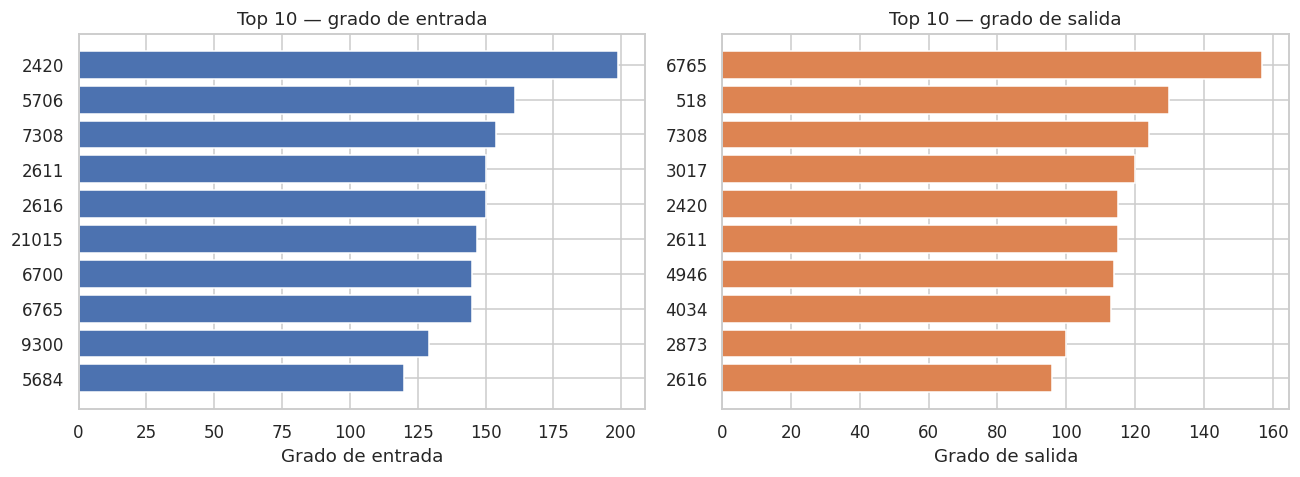

In [33]:
# --- (c) Top 10 nodos por grado de entrada y por grado de salida ---
top_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:TOP_N_DEGREE]
top_out = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:TOP_N_DEGREE]

print(f"Top {TOP_N_DEGREE} nodos por grado de ENTRADA:")
for i, (nodo, grado) in enumerate(top_in, start=1):
    # TODO: si la red tiene etiquetas/nombres legibles, mapear 'nodo' -> etiqueta aquí
    print(f"  {i:2d}. nodo={nodo!s:15s} in-degree={grado}")

print(f"\nTop {TOP_N_DEGREE} nodos por grado de SALIDA:")
for i, (nodo, grado) in enumerate(top_out, start=1):
    print(f"  {i:2d}. nodo={nodo!s:15s} out-degree={grado}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh([str(n_) for n_, _ in top_in][::-1], [d for _, d in top_in][::-1], color="#4C72B0")
axes[0].set_title(f"Top {TOP_N_DEGREE} — grado de entrada")
axes[0].set_xlabel("Grado de entrada")

axes[1].barh([str(n_) for n_, _ in top_out][::-1], [d for _, d in top_out][::-1], color="#DD8452")
axes[1].set_title(f"Top {TOP_N_DEGREE} — grado de salida")
axes[1].set_xlabel("Grado de salida")

plt.tight_layout()
plt.show()


In [34]:
# --- (d) Conexidad de la red ---
# Nota: usamos la versión no dirigida como aproximación rápida de "componentes"
# y evaluamos formalmente la conexidad fuerte del grafo dirigido original.

es_fuertemente_conexo = nx.is_strongly_connected(G)
num_componentes_fuertes = nx.number_strongly_connected_components(G)
num_componentes_debiles = nx.number_weakly_connected_components(G)

print(f"¿Es fuertemente conexo?: {es_fuertemente_conexo}")
print(f"Número de componentes fuertemente conexas: {num_componentes_fuertes}")
print(f"Número de componentes débilmente conexas: {num_componentes_debiles}")

# TODO: comentar en el informe qué implica esto para la interpretación de PageRank.
# Recordar: independientemente de la conexidad del grafo subyacente, la Matriz de
# Google G es siempre irreducible (todas sus entradas son estrictamente positivas
# gracias al término de teletransporte), por lo que el teorema de Perron-Frobenius
# garantiza un único vector propio dominante positivo (el PageRank), sin importar
# si la red original tiene componentes aisladas.


¿Es fuertemente conexo?: False
Número de componentes fuertemente conexas: 15142
Número de componentes débilmente conexas: 1981


## 5. P4: Construcción de la Matriz de Google

Construimos paso a paso $H \to S \to G$, exactamente como en el enunciado:

**(a) Matriz de hipervínculos $H$:**
$$H_{ij} = \begin{cases} 1/\mathrm{out}(j) & \text{si } j \to i \\ 0 & \text{si no} \end{cases}$$

Cada columna $j$ de $H$ suma 1 siempre que el nodo $j$ **no** sea colgante,
porque se reparte una masa total de 1 en partes iguales entre sus
$\mathrm{out}(j)$ vecinos salientes. Las columnas cero corresponden
exactamente a los nodos colgantes identificados en la Sección 4(b).

**(b) Matriz columna-estocástica $S$:**
$$S = H + \frac{1}{n}\,\mathbf{1}\,\mathbf{a}^T, \qquad a_j = \begin{cases}1 & \text{si } j \text{ es colgante}\\ 0 & \text{si no}\end{cases}$$

> **Nota sobre la fórmula:** con la convención de $H$ usada en este enunciado
> ($H_{ij}=1/\mathrm{out}(j)$ si $j\to i$, es decir **columnas** indexadas por
> el nodo fuente), el vector $\mathbf{1}$ debe ir a la izquierda y
> $\mathbf{a}^T$ a la derecha para que la corrección se aplique **columna a
> columna**: la entrada $(i,j)$ de $\frac{1}{n}\mathbf{1}\mathbf{a}^T$ es
> $a_j/n$, así que para cada columna colgante $j$ se suma $1/n$ en **todas**
> las filas $i$, reemplazando esa columna completa por el vector uniforme
> $\mathbf{1}/n$ (tal como pide el enunciado en su descripción textual).
> Verifiquen esta consistencia con su propio material de clase antes de
> reportarla en el informe.

**(c) Matriz de Google $G$:**
$$G = \alpha S + \frac{1-\alpha}{n}\,\mathbf{1}\mathbf{1}^T$$

Usamos matrices **dispersas** (`scipy.sparse`) para $H$ y $S$, ya que son
extremadamente ralas en redes reales ($m \ll n^2$). $G$ en cambio es densa
por construcción (el término de teletransporte añade masa positiva a *todas*
las entradas), por lo que en la práctica **nunca la formamos explícitamente**:
en la iteración de potencias (Sección 6) aplicamos el producto $Gr$ de forma
algebraica, evitando construir una matriz $n\times n$ densa en memoria.


In [35]:
# Orden fijo de nodos para pasar de networkx a índices matriciales
nodos_lista = list(G.nodes())
n = len(nodos_lista)
idx_de_nodo = {nodo: i for i, nodo in enumerate(nodos_lista)}

# --- (a) Matriz de hipervínculos H (dispersa, formato CSC para trabajar por columnas) ---
filas, columnas, datos = [], [], []
for j_nodo in nodos_lista:
    j = idx_de_nodo[j_nodo]
    out_j = out_degrees[j_nodo]
    if out_j == 0:
        continue  # nodo colgante -> columna queda en cero, se corrige en S
    peso = 1.0 / out_j
    for _, i_nodo in G.out_edges(j_nodo):
        i = idx_de_nodo[i_nodo]
        filas.append(i)
        columnas.append(j)
        datos.append(peso)

H = sp.csc_matrix((datos, (filas, columnas)), shape=(n, n))

# Validación: cada columna no colgante debe sumar 1
sumas_columnas_H = np.asarray(H.sum(axis=0)).flatten()
columnas_no_colgantes = np.array([out_degrees[nodo] > 0 for nodo in nodos_lista])
assert np.allclose(sumas_columnas_H[columnas_no_colgantes], 1.0, atol=1e-9), (
    "Hay columnas no colgantes de H que no suman 1. Revisar construcción de H."
)
print(f"H construida: shape={H.shape}, no-ceros={H.nnz}")
print(f"Columnas cero (nodos colgantes): {int(np.sum(sumas_columnas_H == 0))} "
      f"({np.sum(sumas_columnas_H == 0) / n:.2%} del total)")


H construida: shape=(46952, 46952), no-ceros=274086
Columnas cero (nodos colgantes): 4562 (9.72% del total)


In [36]:
# --- (b) Matriz columna-estocástica S ---
# Vector indicador de nodos colgantes: a_j = 1 si col j es cero
vector_a = (sumas_columnas_H == 0).astype(float)

def aplicar_S(r_vec, H, vector_a, n):
    """Calcula S @ r_vec sin formar S de forma densa.

    S = H + (1/n) * 1 * a^T  =>  S @ r = H @ r + (1/n) * (a . r) * 1

    Es decir: la masa total que "cae" en nodos colgantes (a . r = suma de
    r_j sobre los nodos colgantes j) se redistribuye de forma uniforme
    entre TODOS los nodos (vector de puros 1 escalado por esa masa / n).
    """
    masa_colgante = np.dot(vector_a, r_vec)
    return H.dot(r_vec) + (masa_colgante / n)

# Verificación de que S es columna-estocástica (cada columna suma 1):
# construimos S densa SOLO si n es pequeño, ya que S es una matriz n x n densa.
S_dense_check_ok = True
if n <= 2000:  # evitar construir matriz densa n x n si la red es grande
    S_full = H.toarray() + np.outer(np.ones(n), vector_a) / n
    sumas_S = S_full.sum(axis=0)
    S_dense_check_ok = np.allclose(sumas_S, 1.0, atol=1e-8)
    print(f"[Verificación en denso, n<=2000] Todas las columnas de S suman 1: {S_dense_check_ok}")
    assert S_dense_check_ok, "S no quedó columna-estocástica; revisar construcción de H o vector_a."
else:
    # Para redes grandes, verificamos indirectamente: si r es una distribución de
    # probabilidad (suma 1), S@r también debe sumar 1 exactamente.
    r_prueba = np.ones(n) / n
    suma_Sr = np.sum(aplicar_S(r_prueba, H, vector_a, n))
    S_dense_check_ok = np.isclose(suma_Sr, 1.0, atol=1e-8)
    print(f"[Verificación indirecta, n>2000] suma(S @ r) con r distribución uniforme: {suma_Sr:.10f} "
          f"(¿≈1?: {S_dense_check_ok})")
    assert S_dense_check_ok, "S no preserva la masa de probabilidad; revisar construcción de H o vector_a."


[Verificación indirecta, n>2000] suma(S @ r) con r distribución uniforme: 1.0000000000 (¿≈1?: True)


In [37]:
# --- (c) Matriz de Google G (aplicada de forma matriz-vector, nunca formada explícitamente) ---
def aplicar_G(r_vec, H, vector_a, n, alpha):
    """Calcula G @ r_vec = alpha * S @ r_vec + ((1-alpha)/n) * 1 (ya que 1^T r_vec = 1 si r_vec es distribución de prob.).

    Nota: se asume que r_vec suma 1 (es una distribución de probabilidad válida),
    condición que se mantiene en cada paso de la iteración de potencias.
    """
    Sr = aplicar_S(r_vec, H, vector_a, n)
    return alpha * Sr + (1 - alpha) / n * np.ones(n)


# Todas las entradas de G son estrictamente positivas porque el término de
# teletransporte (1-alpha)/n * 1 * 1^T añade una masa positiva uniforme a cada
# entrada, incluso donde H (y por lo tanto S) tiene ceros. Esto hace que G sea
# una matriz irreducible y aperiódica (Perron-Frobenius), garantizando un único
# vector propio dominante positivo asociado al valor propio 1.

print(f"Matriz de Google definida implícitamente vía aplicar_G(), con alpha={ALPHA}.")
print("G nunca se materializa como matriz densa n x n para no comprometer memoria/tiempo.")


Matriz de Google definida implícitamente vía aplicar_G(), con alpha=0.85.
G nunca se materializa como matriz densa n x n para no comprometer memoria/tiempo.


## 6. P5: Cálculo del PageRank mediante iteración de potencias

Implementamos la iteración de potencias:
$$\mathbf{r}^{(k+1)} = G\,\mathbf{r}^{(k)}, \qquad \mathbf{r}^{(0)} = \frac{1}{n}\mathbf{1}$$

deteniendo cuando $\lVert \mathbf{r}^{(k+1)} - \mathbf{r}^{(k)} \rVert_1 < \varepsilon$,
con $\varepsilon = 10^{-10}$.


In [38]:
def iteracion_potencias_pagerank(H, vector_a, n, alpha=ALPHA, tol=TOL, max_iter=MAX_ITER):
    """Calcula el PageRank mediante iteración de potencias sobre la Matriz de Google.

    Returns
    -------
    r : np.ndarray
        Vector de PageRank normalizado (suma 1).
    historial_error : list[float]
        Error L1 entre iteraciones consecutivas, por iteración.
    """
    r = np.full(n, 1.0 / n)
    historial_error = []

    for k in range(1, max_iter + 1):
        r_nuevo = aplicar_G(r, H, vector_a, n, alpha)
        error = np.sum(np.abs(r_nuevo - r))  # norma L1
        historial_error.append(error)
        r = r_nuevo
        if error < tol:
            print(f"Convergencia alcanzada en {k} iteraciones (error={error:.2e} < tol={tol:.0e}).")
            return r, historial_error

    print(f"[AVISO] No se alcanzó la tolerancia tras {max_iter} iteraciones "
          f"(último error={historial_error[-1]:.2e}). Considere aumentar MAX_ITER.")
    return r, historial_error


pagerank_vec, historial_error = iteracion_potencias_pagerank(H, vector_a, n)
print(f"Número de iteraciones realizadas: {len(historial_error)}")


Convergencia alcanzada en 114 iteraciones (error=8.89e-11 < tol=1e-10).
Número de iteraciones realizadas: 114


### 6.1 Curva de convergencia

Graficamos el error $\lVert r^{(k)} - r^{(k-1)} \rVert_1$ en función de $k$
en escala logarítmica, y verificamos que el decaimiento sea geométrico con
razón aproximada $\alpha$ (propiedad conocida de la iteración de potencias
sobre $G$: la brecha espectral entre el primer y segundo valor propio de $G$
está acotada por $\alpha$, lo que determina la tasa de convergencia).


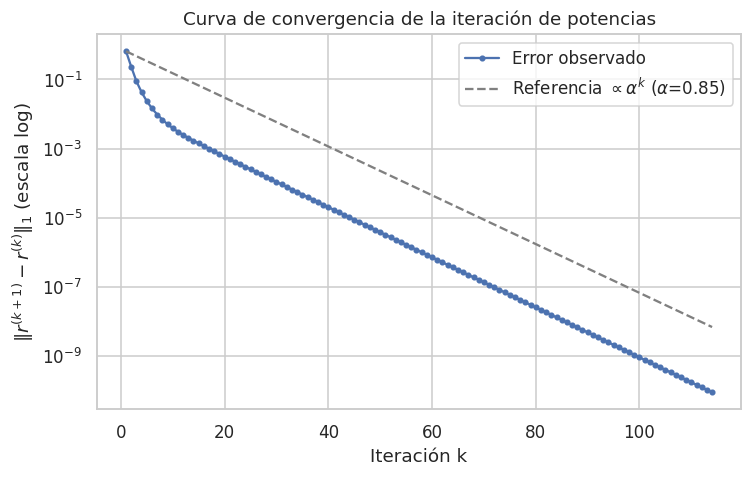

In [39]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(historial_error) + 1), historial_error, marker="o", markersize=3,
        color="#4C72B0", label="Error observado")
ax.set_yscale("log")
ax.set_xlabel("Iteración k")
ax.set_ylabel(r"$\|r^{(k+1)} - r^{(k)}\|_1$ (escala log)")
ax.set_title("Curva de convergencia de la iteración de potencias")

# Referencia teórica: decaimiento geométrico ~ alpha^k (normalizado al primer error observado)
if len(historial_error) > 1:
    referencia = historial_error[0] * (ALPHA ** np.arange(len(historial_error)))
    ax.plot(range(1, len(historial_error) + 1), referencia, "--", color="gray",
            label=fr"Referencia $\propto \alpha^k$ ($\alpha$={ALPHA})")

ax.legend()
plt.tight_layout()
plt.show()

# TODO: comentar en el informe si el decaimiento observado es consistente con
# la razón teórica alpha, o si difiere (y por qué podría diferir).


### 6.2 Verificación de propiedades teóricas

Verificamos que $\lVert r^* \rVert_1 = 1$ (el PageRank es una distribución de
probabilidad, garantizado porque $G$ es columna-estocástica: cada paso de la
iteración preserva la masa total) y que $r_i^* > 0$ para todo $i$
(garantizado por el teorema de Perron-Frobenius, ya que $G$ es irreducible y
aperiódica: todas sus entradas son estrictamente positivas gracias al
término de teletransporte).


In [40]:
suma_pagerank = np.sum(pagerank_vec)
todos_positivos = np.all(pagerank_vec > 0)

print(f"Suma total del PageRank (debe ser ~1): {suma_pagerank:.12f}")
print(f"¿Todos los valores de PageRank son estrictamente positivos?: {todos_positivos}")

assert np.isclose(suma_pagerank, 1.0, atol=1e-6), "El PageRank no está normalizado correctamente."
assert todos_positivos, "Se encontraron valores de PageRank no positivos; revisar construcción de G."


Suma total del PageRank (debe ser ~1): 1.000000000000
¿Todos los valores de PageRank son estrictamente positivos?: True


### 6.3 Tabla de los 20 nodos de mayor PageRank


In [41]:
orden_pagerank = np.argsort(-pagerank_vec)
top_pr_idx = orden_pagerank[:TOP_N_PAGERANK]

print(f"{'Rango':<6}{'Nodo/ID':<20}{'PageRank':<14}{'In-degree':<12}{'Out-degree':<10}")
tabla_top_pagerank = []
for rango, idx in enumerate(top_pr_idx, start=1):
    nodo = nodos_lista[idx]
    fila = {
        "rango": rango,
        "nodo": nodo,
        # TODO: si la red tiene nombres/etiquetas legibles (título, usuario, URL),
        # mapearlos aquí en vez de mostrar solo el id crudo del nodo.
        "pagerank": pagerank_vec[idx],
        "in_degree": in_degrees[nodo],
        "out_degree": out_degrees[nodo],
    }
    tabla_top_pagerank.append(fila)
    print(f"{rango:<6}{str(nodo):<20}{pagerank_vec[idx]:<14.6e}{in_degrees[nodo]:<12}{out_degrees[nodo]:<10}")

# TODO: exportar esta tabla a un formato apto para el informe (p.ej. pandas.DataFrame.to_latex()
# o to_markdown()) si se dispone de pandas.


Rango Nodo/ID             PageRank      In-degree   Out-degree
1     16177               6.011973e-04  30          1         
2     272                 4.555419e-04  31          1         
3     6716                4.343513e-04  48          1         
4     10410               4.191646e-04  24          1         
5     2420                3.472436e-04  199         115       
6     4211                3.424438e-04  23          1         
7     3361                3.330337e-04  119         52        
8     7308                3.242477e-04  154         124       
9     9300                3.229802e-04  129         88        
10    15719               3.139392e-04  14          1         
11    26171               2.943829e-04  98          0         
12    2611                2.937524e-04  150         115       
13    425                 2.803480e-04  109         90        
14    21513               2.765703e-04  103         90        
15    2712                2.712635e-04  117         46 

## 7. P6: PageRank vs. grado de entrada

Comparamos PageRank con la centralidad de grado de entrada para verificar
si PageRank aporta información más allá de un simple conteo de enlaces
entrantes.


Coeficiente de correlación de Pearson (in-degree vs PageRank): 0.8169
p-valor: 0.00e+00


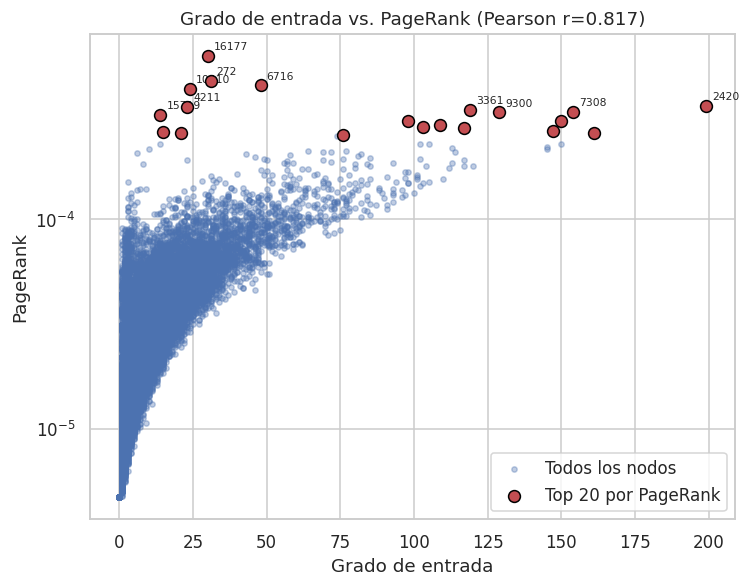

In [42]:
in_degree_vec = np.array([in_degrees[nodo] for nodo in nodos_lista])

coef_pearson, p_valor = pearsonr(in_degree_vec, pagerank_vec)
print(f"Coeficiente de correlación de Pearson (in-degree vs PageRank): {coef_pearson:.4f}")
print(f"p-valor: {p_valor:.2e}")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(in_degree_vec, pagerank_vec, s=12, alpha=0.35, color="#4C72B0", label="Todos los nodos")
ax.scatter(in_degree_vec[top_pr_idx], pagerank_vec[top_pr_idx], s=60, color="#C44E52",
           edgecolor="black", zorder=5, label=f"Top {TOP_N_PAGERANK} por PageRank")

for idx in top_pr_idx[:TOP_N_DEGREE]:
    ax.annotate(str(nodos_lista[idx]), (in_degree_vec[idx], pagerank_vec[idx]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Grado de entrada")
ax.set_ylabel("PageRank")
ax.set_yscale("log")
ax.set_title(f"Grado de entrada vs. PageRank (Pearson r={coef_pearson:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


### 7.1 Identificación de nodos con comportamiento divergente

Buscamos: (i) un nodo con **alto grado de entrada pero PageRank
relativamente bajo**, y (ii) un nodo con **PageRank alto pero grado de
entrada moderado**. Esto ilustra que PageRank captura una noción recursiva
de importancia ("me enlaza quien es importante"), no solo un conteo simple.


In [43]:
# Ranking normalizado (percentil) de cada nodo según cada métrica
rango_in_degree = np.argsort(np.argsort(-in_degree_vec))   # 0 = mayor in-degree
rango_pagerank = np.argsort(np.argsort(-pagerank_vec))      # 0 = mayor pagerank

# Nodo con alto in-degree pero bajo pagerank relativo: gran diferencia (rango_pr - rango_in) positiva y grande
diferencia_rango = rango_pagerank.astype(int) - rango_in_degree.astype(int)

idx_alto_indeg_bajo_pr = np.argmax(diferencia_rango)   # in-degree "adelantado" respecto a pagerank
idx_alto_pr_moderado_indeg = np.argmin(diferencia_rango)  # pagerank "adelantado" respecto a in-degree

nodo_A = nodos_lista[idx_alto_indeg_bajo_pr]
nodo_B = nodos_lista[idx_alto_pr_moderado_indeg]

print("Nodo con alto in-degree pero PageRank relativamente bajo:")
print(f"  nodo={nodo_A}, in-degree={in_degrees[nodo_A]} (rango #{rango_in_degree[idx_alto_indeg_bajo_pr]+1}), "
      f"pagerank={pagerank_vec[idx_alto_indeg_bajo_pr]:.3e} (rango #{rango_pagerank[idx_alto_indeg_bajo_pr]+1})")

print("\nNodo con PageRank alto pero in-degree moderado:")
print(f"  nodo={nodo_B}, in-degree={in_degrees[nodo_B]} (rango #{rango_in_degree[idx_alto_pr_moderado_indeg]+1}), "
      f"pagerank={pagerank_vec[idx_alto_pr_moderado_indeg]:.3e} (rango #{rango_pagerank[idx_alto_pr_moderado_indeg]+1})")

# TODO: en el informe, explicar en el contexto de la red POR QUÉ estos dos nodos
# muestran esta divergencia (p.ej. el nodo A recibe muchos enlaces "poco valiosos"
# de nodos periféricos, mientras que el nodo B es enlazado por pocos nodos, pero
# estos son a su vez muy influyentes).


Nodo con alto in-degree pero PageRank relativamente bajo:
  nodo=11167, in-degree=9 (rango #8460), pagerank=1.073e-05 (rango #29202)

Nodo con PageRank alto pero in-degree moderado:
  nodo=39260, in-degree=1 (rango #39256), pagerank=9.032e-05 (rango #647)


## 8. P7: Interpretación de resultados

### 8.1 Nodos de mayor PageRank en contexto

> TODO: Redactar un párrafo explicando, con conocimiento del dominio de la
> red elegida, por qué los nodos del top-20 (Sección 6.3) tienen sentido
> como nodos influyentes. Si los nodos tienen identificadores interpretables
> (nombre de usuario, título de artículo, URL, etc.), úsenlos explícitamente
> en la discusión en vez de solo los ids crudos.

### 8.2 Visualización del subgrafo de mayor PageRank

Visualizamos el subgrafo inducido por los `SUBGRAPH_SIZE` nodos de mayor
PageRank (recomendado: entre 30 y 50 — ajustar el parámetro al inicio del
notebook), escalando cada nodo según su PageRank. Si la red tiene atributos
de nodo (categoría, comunidad, tipo), coloreamos por ese atributo.


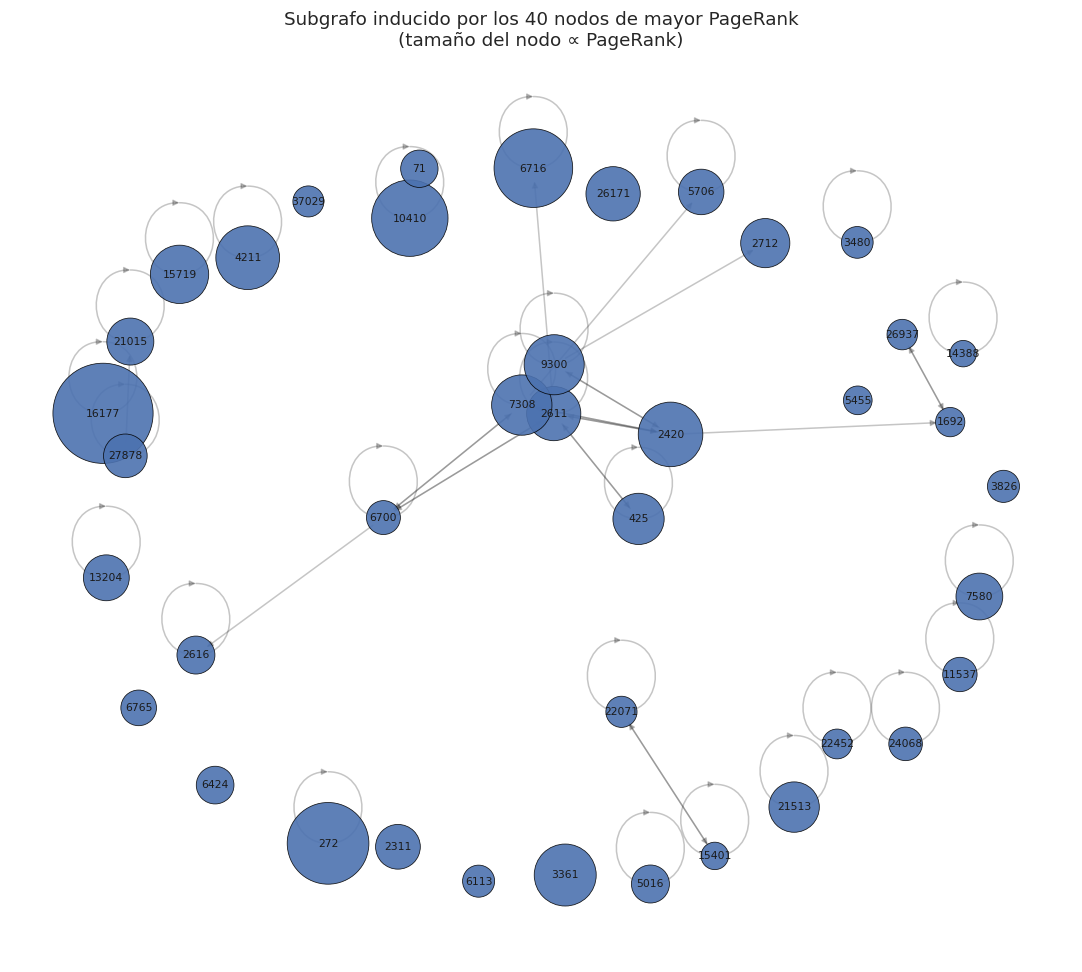

In [44]:
assert 30 <= SUBGRAPH_SIZE <= 50, "El enunciado pide un subgrafo de 30 a 50 nodos; ajustar SUBGRAPH_SIZE."

top_subgrafo_idx = orden_pagerank[:SUBGRAPH_SIZE]
nodos_subgrafo = [nodos_lista[i] for i in top_subgrafo_idx]
subgrafo = G.subgraph(nodos_subgrafo).copy()

pagerank_subgrafo = {nodo: pagerank_vec[idx_de_nodo[nodo]] for nodo in nodos_subgrafo}

# Escalamos tamaños de nodo por PageRank (normalizado para visualización)
valores_pr = np.array(list(pagerank_subgrafo.values()))
tamanos_nodo = 300 + 4000 * (valores_pr - valores_pr.min()) / (valores_pr.max() - valores_pr.min() + 1e-12)

# TODO: si la red tiene un atributo de nodo (categoría/comunidad/tipo), reemplazar
# 'color_por_atributo' por ese atributo real, p.ej.:
# atributo_nodo = nx.get_node_attributes(G, "categoria")
# colores = [atributo_nodo.get(nodo, "desconocido") for nodo in subgrafo.nodes()]
colores = ["#4C72B0"] * subgrafo.number_of_nodes()  # placeholder: un solo color

fig, ax = plt.subplots(figsize=(10, 9))
layout = nx.spring_layout(subgrafo, seed=RANDOM_STATE, k=0.6)

nx.draw_networkx_nodes(
    subgrafo, layout, ax=ax,
    node_size=[tamanos_nodo[nodos_subgrafo.index(n_)] for n_ in subgrafo.nodes()],
    node_color=colores, edgecolors="black", linewidths=0.5, alpha=0.9,
)
nx.draw_networkx_edges(subgrafo, layout, ax=ax, alpha=0.25, arrows=True, arrowsize=8)
nx.draw_networkx_labels(subgrafo, layout, ax=ax, font_size=7)

ax.set_title(f"Subgrafo inducido por los {SUBGRAPH_SIZE} nodos de mayor PageRank\n"
             "(tamaño del nodo ∝ PageRank)")
ax.axis("off")

# TODO: agregar leyenda real si se usa un atributo de nodo para colorear
plt.tight_layout()
plt.show()

# TODO: comentar en el informe la estructura observada (¿hay un núcleo denso?,
# ¿se forman subgrupos/comunidades visibles?, ¿algunos nodos actúan como puentes?)


### 8.3 Relación entre PageRank y atributos de nodo (si existen)

> TODO: Si la red tiene atributos de nodo o etiquetas naturales (por
> ejemplo, orientación política, área temática, país), analizar aquí si los
> nodos de mayor PageRank se concentran en un grupo particular o están
> distribuidos entre grupos. Si la red **no** tiene atributos de este tipo,
> indicarlo explícitamente y justificar por qué esta sub-pregunta no aplica.


In [45]:
# TODO: plantilla opcional para analizar PageRank por atributo/categoría de nodo.
# Descomentar y adaptar si la red tiene un atributo de nodo relevante.

# atributo_nodo = nx.get_node_attributes(G, "TODO_nombre_atributo")
# if atributo_nodo:
#     import collections
#     pr_por_categoria = collections.defaultdict(list)
#     for nodo in nodos_lista:
#         categoria = atributo_nodo.get(nodo, "sin_categoria")
#         pr_por_categoria[categoria].append(pagerank_vec[idx_de_nodo[nodo]])
#
#     for categoria, valores in pr_por_categoria.items():
#         print(f"{categoria:20s}: PageRank medio={np.mean(valores):.3e}, n={len(valores)}")
# else:
#     print("La red no tiene atributos de nodo cargados; completar TODO si aplica.")

print("Sección opcional: completar solo si la red elegida tiene atributos/etiquetas de nodo.")


Sección opcional: completar solo si la red elegida tiene atributos/etiquetas de nodo.


## 9. P8: Discusión, limitaciones y conclusiones

> **¿Se cumplió la hipótesis inicial (Sección 3)? (TODO)**
> Comparar explícitamente los nodos de mayor PageRank obtenidos (Sección
> 6.3 y 8.1) contra la hipótesis planteada en la Sección 3. Indicar
> resultados esperados e inesperados.

> **Limitaciones del método para esta red (TODO)**
> - ¿Tiene sentido el modelo de marcha aleatoria para esta red en particular?
> - ¿Los nodos colgantes (Sección 4b: `TODO% del total`) son frecuentes y
>   afectan significativamente el resultado?
> - ¿La red es demasiado densa o demasiado dispersa (densidad = `TODO`,
>   Sección 2.4) para que PageRank sea informativo?

> **Preguntas nuevas que surgieron del análisis (TODO)**
> Completar con preguntas que no se anticiparon al inicio del proyecto.

> **Explicación no técnica del resultado principal (TODO)**
> Redactar 3-5 oraciones explicando el hallazgo principal a alguien sin
> conocimientos de álgebra lineal ni redes.


## 10. Checklist final y exportación

Antes de entregar, verifiquen automáticamente que los elementos mínimos
exigidos por el enunciado estén presentes, y exporten los artefactos
(tablas, figuras) que acompañarán al informe en PDF.


In [46]:
checklist = {
    "Red dirigida con >=500 nodos y >=2000 aristas": (n_nodos >= 500 and n_aristas >= 2000 and G.is_directed()),
    "Tabla de estadísticas básicas calculada": bool(tabla_estadisticas),
    "Matriz H construida y validada": H.shape == (n, n),
    "Vector de nodos colgantes 'a' definido": vector_a.shape[0] == n,
    "PageRank converge y suma 1": np.isclose(np.sum(pagerank_vec), 1.0, atol=1e-6),
    "Todos los PageRank son positivos": bool(np.all(pagerank_vec > 0)),
    "Tabla top-20 PageRank generada": len(tabla_top_pagerank) == TOP_N_PAGERANK,
    "Correlación PageRank vs in-degree calculada": "coef_pearson" in dir(),
    "Subgrafo de nodos top visualizado": subgrafo.number_of_nodes() > 0 if "subgrafo" in dir() else False,
}

print("=== CHECKLIST DE ENTREGA ===")
for item, cumplido in checklist.items():
    estado = "✅" if cumplido else "❌ TODO"
    print(f"[{estado}] {item}")

# TODO (checklist manual, no automatizable):
# [ ] Red elegida descrita con fuente citada (Sección 2.1)
# [ ] Pregunta e hipótesis inicial documentadas (Sección 3)
# [ ] Discusión final que conecte con la hipótesis inicial (Sección 9)
# [ ] Código reproducible subido a un repositorio público de GitHub,
#     con instrucciones de ejecución y enlace a los datos


=== CHECKLIST DE ENTREGA ===
[✅] Red dirigida con >=500 nodos y >=2000 aristas
[✅] Tabla de estadísticas básicas calculada
[✅] Matriz H construida y validada
[✅] Vector de nodos colgantes 'a' definido
[✅] PageRank converge y suma 1
[✅] Todos los PageRank son positivos
[✅] Tabla top-20 PageRank generada
[✅] Correlación PageRank vs in-degree calculada
[✅] Subgrafo de nodos top visualizado


In [47]:
# --- Exportación de resultados a disco (para adjuntar/reproducir figuras en el informe) ---
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

try:
    np.save(OUTPUT_DIR / "pagerank_vector.npy", pagerank_vec)

    with open(OUTPUT_DIR / "top_pagerank.csv", "w", encoding="utf-8") as f:
        f.write("rango,nodo,pagerank,in_degree,out_degree\n")
        for fila in tabla_top_pagerank:
            f.write(f"{fila['rango']},{fila['nodo']},{fila['pagerank']:.10e},"
                    f"{fila['in_degree']},{fila['out_degree']}\n")

    print(f"Resultados exportados a: {OUTPUT_DIR.resolve()}")
except Exception as e:
    print(f"[AVISO] No se pudieron exportar los resultados: {e}")

# TODO: adjuntar estos archivos al repositorio de GitHub junto con el código,
# tal como exige el enunciado ("archivos necesarios para reproducir figuras y resultados").


Resultados exportados a: /home/uc/Downloads/IMT2230/Tareas/Proyecto2/Proyecto-Algebra2/outputs


---

### Fin del notebook

Recuerden antes de la entrega:

1. Ejecutar el notebook **de principio a fin en un kernel limpio**
   (`Restart & Run All`) para garantizar reproducibilidad.
2. Reemplazar **todos** los `# TODO` (código) y `> TODO` (texto) por
   contenido real y específico de su red.
3. Subir el código a un **repositorio público de GitHub** con instrucciones
   de ejecución y enlace a los datos.
4. Redactar el **informe final en PDF** (puede basarse en las celdas
   markdown de este notebook, reestructurándolas de forma breve y clara).
